In [3]:
import pandas as pd
import numpy as np
import glob
import os
import re
import matplotlib.pyplot as plt

from sklearn import linear_model
from ipywidgets import widgets
from IPython.display import display
from scipy import stats
from typing import List, Any


# Defines what happens when you click the button
def on_click_predict(b):
    if off_rank.value <= 0:
        button_output.value = "Offensive rank must be greater than 0"
        return
    if off_rank.value > max_team_count:
        button_output.value = "Offensive rank cannot be greater than the number of teams"
        return
    if def_rank.value <= 0:
        button_output.value = "Defensive rank must be greater than 0"
        return
    if touchdowns.value < 0:
        button_output.value = "Touchdowns must not be negative"
        return
    
    prediction = multi_reg.predict([[off_rank.value, def_rank.value, touchdowns.value]])
    if int(prediction[0].round(0)) > 15:
        p = '15'
    elif int(prediction[0].round(0)) < 0:
        p = '0'
    else:
        p = str(int(prediction[0].round(0)))
        
    button_output.value = "Prediction = " + p


# Pulls in the slope of the scatter plots
def slope_func(x_axis):
    return slope * x_axis + intercept


# Predicts the wins based on an independent value
def wins_predictor(independent_value, slope_value, intercept_value):
    return slope_value * independent_value + intercept_value


# Returns a dictionary of stats
def get_stats(stats_list, stats_arr):
    mean = stats_list.mean()
    median = stats_list.median()
    mode = stats_list.mode()[0]
    std_dev = stats_list.std()
    var = stats_list.var()
    percent = np.percentile(stats_arr, 75)
    stats_dict = {"mean": mean, "median": median, "mode": mode, "std_dev": std_dev, "var": var, "percent": percent}
    return stats_dict


# rename dataframe columns in a consistent format
def snake_cols(dataframe):
    col: str
    for col in dataframe.columns:
        dataframe.rename(columns={col: col.replace('.', '_')
                         .replace(' ', '_')
                         .replace('/', '_')
                         .replace('X', '')
                         .replace('-', '_').lower()}, inplace=True)


# Remove conferences for year over year consistency
def remove_conferences(dataframe):
    rc = 0
    for tv in dataframe["team"].values:
        tv = re.sub(r"\(.*?\)", "", tv)
        dataframe.at[rc, 'team'] = tv
        rc += 1

In [4]:
path = os.getcwd()
csv_files = glob.glob(os.path.join(path, "*.csv"))
cfb_values = ['team', 'win', 'loss', 'off_rank', 'def_rank', 'touchdowns', 'total_points']
i = 0
df_all = pd.DataFrame
year = 2013
max_team_count = 0

# Loop through all the files and import the ones we want and then make predictions below
for f in csv_files:
    str_Filename = f.split("\\")[-1].upper()
    if str_Filename.__eq__("CFB22.CSV"):
        break

    # read the csv file
    df = pd.read_csv(f)
    # clean up dataframe
    snake_cols(df)
    remove_conferences(df)

    # Add year to teams
    df['team'] = df['team'] + (year + i).__str__()

    # 2021 and 2022 files have some variation in fields - could check for this programatically
    if str_Filename.__eq__("CFB21.CSV"):
        df[['win', 'loss']] = df['win_loss'].str.split('-', expand=True).astype(int)
        df.drop(['win_loss'], axis=1, inplace=True)

    # Reduce dataframe to core fields
    df = df[cfb_values]
    team_count = df['team'].count()
    if team_count > max_team_count:
        max_team_count = team_count
    
    if i == 0:
        df_all = df
    else:
        df_all = pd.concat([df_all, df], axis=0)
    
    i += 1

# Drop all columns with null values
df_all.dropna(axis=1, inplace=True)
# Set the dataframe index to team
df_all.set_index('team', inplace=True)

# Create numeric correlation dataframe 
df_corr = df_all.corr(numeric_only=True)
df_corr

,win,loss,off_rank,def_rank,touchdowns,total_points
win,1.000000,-0.833682,-0.552424,-0.560856,0.805573,0.828339
loss,-0.833682,1.000000,0.552016,0.565991,-0.574211,-0.578242
off_rank,-0.552424,0.552016,1.000000,0.007590,-0.763264,-0.758223
def_rank,-0.560856,0.565991,0.007590,1.000000,-0.193363,-0.212696
touchdowns,0.805573,-0.574211,-0.763264,-0.193363,1.000000,0.990369
total_points,0.828339,-0.578242,-0.758223,-0.212696,0.990369,1.000000


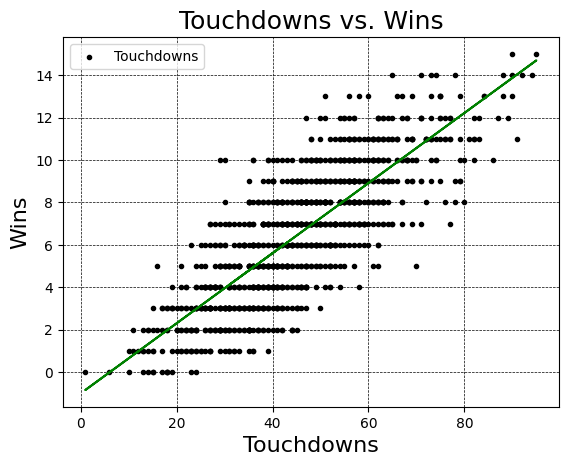

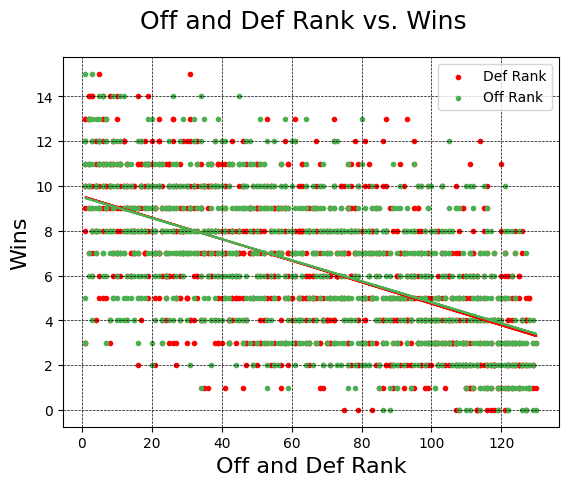

In [5]:
# The following code creates two scatter plots
x = np.array(df_all['touchdowns'])
y = np.array(df_all['win'])
plt.scatter(x, y, color='black', marker='.', label="Touchdowns")

slope, intercept, r, p, std_err = stats.linregress(x, y)

line_slope = list(map(slope_func, x))
plt.plot(x, line_slope, c='green')

plt.xlabel('Touchdowns', fontsize=16)
plt.ylabel('Wins', fontsize=16)
plt.title('Touchdowns vs. Wins', fontsize=18)
plt.legend()
plt.grid(color="black", linestyle="--", linewidth=0.5)
plt.show()

fig, ax = plt.subplots(num="Figure 2")

# Set the x and y values for the scatter plot
x = np.array(df_all["def_rank"])
y = np.array(df_all["win"])

slope, intercept, r, p, std_err = stats.linregress(x, y)

ax.scatter(x, y, color="red", marker=".", label="Def Rank")

line_slope = list(map(slope_func, x))
ax.plot(x, line_slope, color="red")

x = np.array(df_all["off_rank"])

slope, intercept, r, p, std_err = stats.linregress(x, y)

ax.scatter(x, y, color="#4CAF50", marker=".", label="Off Rank")

line_slope = list(map(slope_func, x))
ax.plot(x, line_slope, color="#4CAF50")

ax.set_xlabel("Off and Def Rank", color="black", fontsize=16)
ax.set_ylabel("Wins", color="black", fontsize=16)
ax.grid(color="black", linestyle="--", linewidth=0.5)

fig.suptitle("Off and Def Rank vs. Wins", fontsize=18)
plt.legend()
plt.show()

In [19]:
statistics = get_stats(df_all['touchdowns'], np.array(df_all['touchdowns']))
print("Touchdown statistics for this dataset:")
print("Minimum number of touchdowns:", round(df_all['touchdowns'].min(), 2))
print("Average number of touchdowns:", round(statistics.get("mean"), 2))
print("Maximum number of touchdowns:", round(df_all['touchdowns'].max(), 2))

print("\nThe maximum number of teams from " + str(year) + " to " + str(year + i - 1) + " was " + str(max_team_count) + ",")
print("therefore the max offensive / defensive rank would be " + str(max_team_count) + ".\n")

X = df_all[["off_rank", "def_rank", "touchdowns"]]
y = df_all["win"]

multi_reg = linear_model.LinearRegression()
multi_reg.fit(X, y)
score = multi_reg.score(X, y)

# The text boxes where the user can input values.
off_rank = widgets.FloatText(description='Off Rank:', value='0')
def_rank = widgets.FloatText(description='Def Rank:', value='0')
touchdowns = widgets.FloatText(description='Touchdowns:', value='0')

# A button for the user to get predictions using input values.
button_predict = widgets.Button(description='Predict')
button_output = widgets.Label(value='Enter values and press the \"Predict\" button.')
button_predict.on_click(on_click_predict)

# Displays the text boxes and buttons inside a VBox
vb = widgets.VBox([off_rank, def_rank, touchdowns, button_predict, button_output])
print('\033[1m' + 'Enter values and make a prediction' + '\033[0m')

display(vb)

Touchdown statistics for this dataset:
Minimum number of touchdowns: 1
Average number of touchdowns: 45.28
Maximum number of touchdowns: 95

The maximum number of teams from 2013 to 2021 was 131,
therefore the max offensive / defensive rank would be 131.

Enter values and make a prediction


In [26]:
def_rank_x = np.array(df_all['def_rank'])
off_rank_x = np.array(df_all["off_rank"])
touchdowns_x = np.array(df_all['touchdowns'])
y = np.array(df_all['win'])

def_rank_slope, def_rank_intercept, def_rank_r, def_rank_p, def_rank_std_err = stats.linregress(def_rank_x, y)
off_rank_slope, off_rank_intercept, off_rank_r, off_rank_p, off_rank_std_err = stats.linregress(off_rank_x, y)
touchdowns_slope, touchdowns_intercept, touchdowns_r, touchdowns_p, touchdowns_std_err = stats.linregress(touchdowns_x, y)

offRankInput = input("\nEnter the offensive rank you want to predict: ")
or_predicted_wins = wins_predictor(int(offRankInput), off_rank_slope, off_rank_intercept)
print("\nPredicted wins with an offensive rank of", offRankInput, "is", int(or_predicted_wins.round(0)))

defRankInput = input("\nEnter the defensive rank you want to predict: ")
dr_predicted_wins = wins_predictor(int(defRankInput), def_rank_slope, def_rank_intercept)
print("\nPredicted wins with a defensive rank of", defRankInput, "is", int(dr_predicted_wins.round(0)))

tdsInput = input("\nEnter the number of touchdowns you want to predict: ")
td_predicted_wins = wins_predictor(int(tdsInput), touchdowns_slope, touchdowns_intercept)
print("\nPredicted wins with " + tdsInput + " touchdowns is: " + str(int(td_predicted_wins.round(0))))

df22 = pd.read_csv("cfb22.csv")
snake_cols(df22)
remove_conferences(df22)

df22['team'] = df22['team'] + (year + i).__str__()

df22[['win', 'loss']] = df22['win_loss'].str.split('-', expand=True).astype(int)
df22.drop(['win_loss'], axis=1, inplace=True)

df22 = df22[cfb_values]
team_count = df22['team'].count()
if team_count > max_team_count:
    max_team_count = team_count


Enter the offensive rank you want to predict:  4



Predicted wins with an offensive rank of 4 is 9



Enter the defensive rank you want to predict:  1



Predicted wins with a defensive rank of 1 is 9



Enter the number of touchdowns you want to predict:  37



Predicted wins with 37 touchdowns is: 5


In [13]:
value = int(offRankInput)
output = df22.query('off_rank == @value')
print('\n\033[1m' + '*** Team in ' + str(year + i) + ' with an offensive rank of ' + offRankInput + ': ***' + '\033[0m')
output[['team', 'off_rank', 'win']]


*** Team in 2022 with an offensive rank of 4: ***


,team,off_rank,win
3,UCLA 2022,4,9


In [14]:
value = int(defRankInput)
output = df22.query('def_rank == @value')
print('\n\033[1m' + '*** Team in ' + str(year + i) + ' with a defensive rank of ' + defRankInput + ': ***' + '\033[0m')
output[['team', 'def_rank', 'win']]


*** Team in 2022 with a defensive rank of 1: ***


,team,def_rank,win
58,Air Force 2022,1,10


In [15]:
value = int(tdsInput)
output = df22.query('touchdowns == @value or touchdowns == @value-1 or touchdowns == @value+1')
print('\n\033[1m' + '*** Teams in ' + str(year + i) + ' with ' + tdsInput + ' (+/-1) touchdowns: ***' + '\033[0m')
output[['team', 'touchdowns', 'win']]


*** Teams in 2022 with 37 (+/-1) touchdowns: ***


,team,touchdowns,win
71,Illinois 2022,36,8
81,Missouri 2022,37,6
88,California 2022,36,4
95,Utah St. 2022,36,6
97,UNLV 2022,37,5
107,Bowling Green 2022,38,6


In [25]:
print('\n\033[1m' + '*** Calculated Multi Regression Score: ***' + '\033[0m')
print('\n\033[1m' + str(score.round(4)) + '\033[0m')


*** Calculated Multi Regression Score: ***

0.8194
